# 02 · Keyword baseline sentiment

Baseline text signals for GME / AMC / BB using the **Loughran-McDonald (LM) financial dictionary**.

**Input** (from `01_fnspid_meme_news_extraction`): `fnspid_meme_clean.csv`, `prices_gme_amc_bb.csv`

**Output**: `articles_scored_keyword.csv` (one row per article), `daily_signals_keyword.csv` (one row per ticker × trading day)

Daily metrics, built from each article's bearish / neutral / bullish distribution:

| Metric | Definition | Range |
|---|---|---|
| `sentiment` | mean over articles of (p_bull − p_bear) | −1 … 1 |
| `clarity` | mean over articles of \|p_bull − p_bear\| — how strongly articles lean, either way | 0 … 1 |
| `ambiguity` | normalized entropy of the day's average distribution — high when news is split or neutral | 0 … 1 |
| `uncertainty_rate` | LM "uncertainty" words per 100 words | ≥ 0 |
| `n_articles` / `log_volume_text` | text volume | ≥ 0 |

For the keyword baseline each article gets a hard label, so p is one-hot. `03_finbert_sentiment` will reuse the same `daily_metrics()` function with FinBERT's soft probabilities.

## 0. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ------------------------------------------------------------------
# Project paths: shared Google Drive folder "dl-quant_project"
# Works for the owner and for teammates who added a shortcut to the
# shared folder in their My Drive (see 00_START_HERE_collaboration).
# ------------------------------------------------------------------
import os, glob

def find_project_dir(name="dl-quant_project"):
    candidates = [
        f"/content/drive/MyDrive/Colab Notebooks/{name}",
        f"/content/drive/MyDrive/{name}",
        *glob.glob(f"/content/drive/MyDrive/*/{name}"),
        *glob.glob(f"/content/drive/Shareddrives/*/{name}"),
    ]
    for p in candidates:
        if os.path.isdir(p):
            return p
    raise FileNotFoundError(
        f"Could not find the '{name}' folder in your Google Drive.\n"
        "Fix: Google Drive > Shared with me > right-click 'dl-quant_project' > "
        "Organize > Add shortcut > My Drive. Then re-run this cell.")

PROJECT_DIR  = find_project_dir()
DATA_DIR     = os.path.join(PROJECT_DIR, "DataSource")       # all data files: read AND save here
NOTEBOOK_DIR = os.path.join(PROJECT_DIR, "PythonNoteBooks")  # notebooks
os.makedirs(DATA_DIR, exist_ok=True)
drive_folder = DATA_DIR   # older cells use this name
print("Project folder:", PROJECT_DIR)
print("Data folder:   ", DATA_DIR)

import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

drive_folder = DATA_DIR  # data folder defined in the setup cell
TICKERS = ["GME", "AMC", "BB"]

# Optional: add common market-move words that LM (built from 10-K filings) misses,
# e.g. "soars", "plunges". Keep False for the pure, reproducible LM baseline.
USE_MARKET_WORDS = True

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Load the cleaned news

In [ ]:
news = pd.read_csv(os.path.join(drive_folder, "fnspid_meme_clean.csv"),
                   parse_dates=["date", "target_date"])
print(news.shape)
print(news.groupby("ticker").size())
news.head(3)

(9538, 9)
ticker
AMC    3229
BB     1139
GME    5170
dtype: int64


,ticker,date,target_date,Article_title,text,title_hits,body_hits,Publisher,Url
0,AMC,2023-12-12,2023-12-13,"Zacks Industry Outlook Highlights Royal Caribbean Cruises, Live Nation Entertainment and AMC Entertainment Holdings","Zacks Industry Outlook Highlights Royal Caribbean Cruises, Live Nation Entertainment and AMC Entertainment Holdings....",1,8,NaN,https://www.nasdaq.com/articles/zacks-industry-outlook-highlights-royal-caribbean-cruises-live-nation-entertainment-...
1,AMC,2023-12-12,2023-12-13,Rate Cut Reactions: 7 Meme Stocks to Buy or Sell Now,"Rate Cut Reactions: 7 Meme Stocks to Buy or Sell Now. InvestorPlace - Stock Market News, Stock Advice & Trading Tips...",0,11,NaN,https://www.nasdaq.com/articles/rate-cut-reactions%3A-7-meme-stocks-to-buy-or-sell-now
2,AMC,2023-12-11,2023-12-12,3 Stocks to Watch From Leisure & Recreation Services Industry,3 Stocks to Watch From Leisure & Recreation Services Industry. The Zacks Leisure and Recreation Services industry is...,0,8,NaN,https://www.nasdaq.com/articles/3-stocks-to-watch-from-leisure-recreation-services-industry


## 2. Load the Loughran-McDonald dictionary

In [ ]:
# pysentiment2 ships the full LM master dictionary (Positive / Negative / Uncertainty / ...)
!pip -q install pysentiment2
import pysentiment2, os
lm_path = os.path.join(os.path.dirname(pysentiment2.__file__), "static", "LM.csv")
lm = pd.read_csv(lm_path)

POS = set(lm.loc[lm["Positive"] > 0, "Word"].str.upper())
NEG = set(lm.loc[lm["Negative"] > 0, "Word"].str.upper())
UNC = set(lm.loc[lm["Uncertainty"] > 0, "Word"].str.upper())

if USE_MARKET_WORDS:
    POS |= {"SOAR", "SOARS", "SOARED", "SOARING", "SURGE", "SURGES", "SURGED", "SURGING",
            "RALLY", "RALLIES", "RALLIED", "JUMP", "JUMPS", "JUMPED", "SPIKE", "SPIKES",
            "SPIKED", "SKYROCKET", "SKYROCKETS", "SKYROCKETED", "BULLISH", "UPGRADE", "UPGRADED"}
    NEG |= {"PLUNGE", "PLUNGES", "PLUNGED", "TUMBLE", "TUMBLES", "TUMBLED", "SLUMP", "SLUMPS",
            "SLUMPED", "SINK", "SINKS", "SANK", "CRASH", "CRASHES", "CRASHED", "BEARISH",
            "DOWNGRADE", "DOWNGRADED", "SELLOFF"}

print(f"positive: {len(POS)}, negative: {len(NEG)}, uncertainty: {len(UNC)} words")

positive: 377, negative: 2372, uncertainty: 297 words


## 3. Score each article

In [ ]:
TOKEN_RE = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")

def lm_counts(text):
    """Return (n_words, n_pos, n_neg, n_unc) for one text using exact LM word matches."""
    words = [w.upper() for w in TOKEN_RE.findall(str(text))]
    return (len(words),
            sum(w in POS for w in words),
            sum(w in NEG for w in words),
            sum(w in UNC for w in words))

counts = np.array([lm_counts(t) for t in news["text"].fillna("")])
news["n_words"], news["n_pos"], news["n_neg"], news["n_unc"] = counts.T

# Article tone in [-1, 1]; 0 when there are no positive or negative words
hits = news["n_pos"] + news["n_neg"]
news["tone"] = np.where(hits > 0, (news["n_pos"] - news["n_neg"]) / hits.clip(lower=1), 0.0)

# Hard label -> one-hot probabilities, so the same daily_metrics() works for FinBERT later
news["label"] = np.select([news["tone"] > 0, news["tone"] < 0], ["bullish", "bearish"], "neutral")
news["p_bull"] = (news["label"] == "bullish").astype(float)
news["p_bear"] = (news["label"] == "bearish").astype(float)
news["p_neu"]  = (news["label"] == "neutral").astype(float)

print(pd.crosstab(news["ticker"], news["label"], normalize="index").round(3))

pd.set_option("display.max_colwidth", 120)
print("\nMost bullish headlines:")
print(news.sort_values(["tone", "n_pos"], ascending=False)[["ticker", "date", "Article_title"]].head(5).to_string())
print("\nMost bearish headlines:")
print(news.sort_values(["tone", "n_neg"], ascending=[True, False])[["ticker", "date", "Article_title"]].head(5).to_string())

label   bearish  bullish  neutral
ticker                           
AMC       0.377    0.402    0.221
BB        0.421    0.462    0.118
GME       0.322    0.309    0.369

Most bullish headlines:
     ticker       date                                                           Article_title
6791    GME 2014-11-17  Will Best Buy (BBY) Earnings Top Estimates This Season? - Analyst Blog
6631    GME 2016-03-18            Can Nike's (NKE) Q3 Earnings Keep the Positive Streak Alive?
6567    GME 2016-08-19                 Best Buy (BBY) Q2 Earnings Awaited: What to Anticipate?
2290    AMC 2019-03-05       Here’s Why The Rally In AMC Entertainment Stock Looks Good To $20
6573    GME 2016-08-09                Here Are the Best Consumer Electronics Stocks to Buy Now

Most bearish headlines:
     ticker       date                                                               Article_title
4850    GME 2021-07-15          Why BlackBerry, GameStop, and Kodak Stocks Got Destroyed This Week
1653    AMC 

## 4. How good is the keyword baseline? (Twitter Financial News Sentiment)

Same 3 classes as our project. This gives the number the fine-tuned encoder in `03` has to beat
(Check-in 1 KPI: ≥ 70% accuracy on the validation set).

In [ ]:
!pip -q install datasets
from datasets import load_dataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

tfns = load_dataset("zeroshot/twitter-financial-news-sentiment", split="validation").to_pandas()
id2label = {0: "bearish", 1: "bullish", 2: "neutral"}
tfns["true"] = tfns["label"].map(id2label)

c = np.array([lm_counts(t) for t in tfns["text"]])
tone = np.where(c[:, 1] + c[:, 2] > 0, (c[:, 1] - c[:, 2]) / np.maximum(c[:, 1] + c[:, 2], 1), 0)
tfns["pred"] = np.select([tone > 0, tone < 0], ["bullish", "bearish"], "neutral")

labels = ["bearish", "neutral", "bullish"]
print(f"Accuracy: {accuracy_score(tfns['true'], tfns['pred']):.3f}  (n = {len(tfns)})")
print(f"Majority-class accuracy: {tfns['true'].value_counts(normalize=True).max():.3f}")
print(classification_report(tfns["true"], tfns["pred"], labels=labels, digits=3))
print(pd.DataFrame(confusion_matrix(tfns["true"], tfns["pred"], labels=labels),
                   index=[f"true_{l}" for l in labels], columns=[f"pred_{l}" for l in labels]))

Accuracy: 0.621  (n = 2388)
Majority-class accuracy: 0.656
              precision    recall  f1-score   support

     bearish      0.389     0.539     0.452       347
     neutral      0.718     0.750     0.734      1566
     bullish      0.450     0.257     0.327       475

    accuracy                          0.621      2388
   macro avg      0.519     0.515     0.504      2388
weighted avg      0.617     0.621     0.612      2388

              pred_bearish  pred_neutral  pred_bullish
true_bearish           187           148            12
true_neutral           254          1175           137
true_bullish            40           313           122


## 5. Aggregate to daily signals (ticker × target_date)

In [ ]:
def daily_metrics(df, date_col="target_date"):
    """Aggregate article-level p_bull / p_neu / p_bear into daily signals.
    Works for hard (one-hot) keyword labels and for soft FinBERT probabilities."""
    g = df.assign(net=df["p_bull"] - df["p_bear"],
                  strength=(df["p_bull"] - df["p_bear"]).abs()) \
          .groupby(["ticker", date_col])
    out = g.agg(n_articles=("net", "size"),
                sentiment=("net", "mean"),
                clarity=("strength", "mean"),
                p_bull=("p_bull", "mean"),
                p_neu=("p_neu", "mean"),
                p_bear=("p_bear", "mean"),
                n_words=("n_words", "sum"),
                n_unc=("n_unc", "sum")).reset_index()
    p = out[["p_bull", "p_neu", "p_bear"]].to_numpy()
    ent = -(p * np.log(np.clip(p, 1e-12, 1))).sum(axis=1) / np.log(3)   # normalized to [0, 1]; clip avoids log(0) warnings
    out["ambiguity"] = np.clip(ent, 0, 1) + 0.0   # + 0.0 turns -0.0 into 0.0
    out["uncertainty_rate"] = 100 * out["n_unc"] / out["n_words"].clip(lower=1)
    out["log_volume_text"] = np.log1p(out["n_articles"])
    return out.rename(columns={date_col: "date"})

daily = daily_metrics(news)
print(daily.shape)
print(daily.groupby("ticker")[["n_articles", "sentiment", "clarity", "ambiguity", "uncertainty_rate"]]
          .describe().T.round(3))

(3745, 13)
ticker                       AMC       BB       GME
n_articles       count  1292.000  625.000  1828.000
                 mean      2.499    1.822     2.828
                 std       2.276    1.559     3.686
                 min       1.000    1.000     1.000
                 25%       1.000    1.000     1.000
                 50%       2.000    1.000     2.000
                 75%       3.000    2.000     3.000
                 max      24.000   13.000    56.000
sentiment        count  1292.000  625.000  1828.000
                 mean      0.007   -0.011     0.004
                 std       0.701    0.852     0.638
                 min      -1.000   -1.000    -1.000
                 25%      -0.500   -1.000    -0.420
                 50%       0.000    0.000     0.000
                 75%       0.500    1.000     0.500
                 max       1.000    1.000     1.000
clarity          count  1292.000  625.000  1828.000
                 mean      0.745    0.896     0.604
 

## 6. Merge with prices and save

In [ ]:
px = pd.read_csv(os.path.join(drive_folder, "prices_gme_amc_bb.csv"),
                 header=[0, 1], index_col=0, parse_dates=True)

# Wide yfinance table -> long table: one row per ticker x trading day
frames = []
for t in TICKERS:
    d = px.xs(t, axis=1, level=1).copy()
    d.columns = [c.lower().replace(" ", "_") for c in d.columns]
    d["ticker"] = t
    frames.append(d.reset_index().rename(columns={d.index.name or "index": "date", "Date": "date"}))
prices = pd.concat(frames, ignore_index=True)
prices["date"] = pd.to_datetime(prices["date"]).dt.normalize()
prices = prices.dropna(subset=["close"]).sort_values(["ticker", "date"])

# Simple market variables for a first look (full feature set comes in 04)
prices["ret"] = prices.groupby("ticker")["adj_close"].transform(lambda s: np.log(s).diff())
prices["abs_ret"] = prices["ret"].abs()
prices["log_volume"] = np.log1p(prices["volume"])

panel = prices.merge(daily, on=["ticker", "date"], how="left")
panel["n_articles"] = panel["n_articles"].fillna(0)
panel["has_news"] = (panel["n_articles"] > 0).astype(int)
for col in ["sentiment", "clarity", "ambiguity", "uncertainty_rate", "log_volume_text"]:
    panel[col] = panel[col].fillna(0.0)   # no news -> no signal

news.drop(columns=["text"]).to_csv(os.path.join(drive_folder, "articles_scored_keyword.csv"), index=False)
daily.to_csv(os.path.join(drive_folder, "daily_signals_keyword.csv"), index=False)
panel.to_csv(os.path.join(drive_folder, "panel_keyword_quicklook.csv"), index=False)
print("Saved articles_scored_keyword.csv, daily_signals_keyword.csv, panel_keyword_quicklook.csv")
print(panel.groupby("ticker")["has_news"].mean().rename("share of trading days with news").round(3))

Saved articles_scored_keyword.csv, daily_signals_keyword.csv, panel_keyword_quicklook.csv
ticker
AMC    0.509
BB     0.166
GME    0.484
Name: share of trading days with news, dtype: float64


## 7. Quick look (2021)

Signals on `date` only use news published **before** that trading day (target_date = D+1), so these
correlations are not look-ahead. They are descriptive only; the real tests come in `04` / `05`.

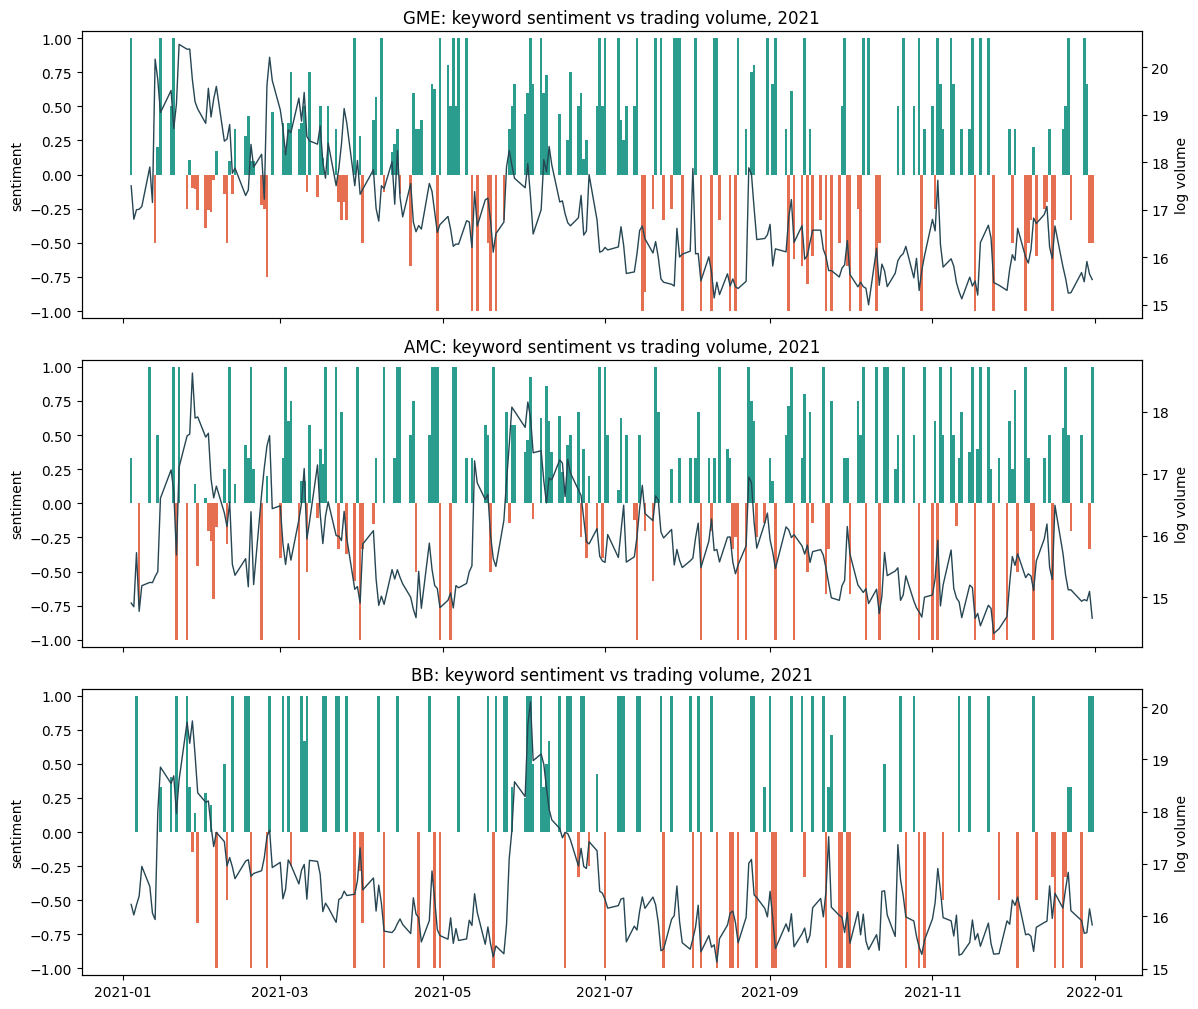

Correlation with same-day |return| (2021):
        sentiment  clarity  ambiguity  uncertainty_rate  log_volume_text
ticker                                                                  
AMC        -0.031    0.046      0.171             0.015            0.204
BB          0.070    0.129      0.232             0.060            0.309
GME        -0.099    0.002      0.253            -0.045            0.382

Correlation with same-day log volume (2021):
        sentiment  clarity  ambiguity  uncertainty_rate  log_volume_text
ticker                                                                  
AMC         0.028    0.101      0.316             0.044            0.448
BB          0.175    0.260      0.430             0.161            0.515
GME         0.011    0.086      0.412            -0.090            0.535


/tmp/ipykernel_3523/1441417276.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d[cols].corrwith(d["abs_ret"]))
/tmp/ipykernel_3523/1441417276.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d[cols].corrwith(d["log_volume"]))


In [ ]:
p21 = panel[(panel["date"] >= "2021-01-01") & (panel["date"] <= "2021-12-31")]

fig, axes = plt.subplots(len(TICKERS), 1, figsize=(12, 3.4 * len(TICKERS)), sharex=True)
for ax, t in zip(axes, TICKERS):
    d = p21[p21["ticker"] == t]
    ax.bar(d["date"], d["sentiment"], color=np.where(d["sentiment"] >= 0, "#2a9d8f", "#e76f51"),
           width=1.0, label="sentiment")
    ax.set_ylim(-1.05, 1.05)
    ax.set_ylabel("sentiment")
    ax2 = ax.twinx()
    ax2.plot(d["date"], d["log_volume"], color="#264653", lw=1, label="log volume")
    ax2.set_ylabel("log volume")
    ax.set_title(f"{t}: keyword sentiment vs trading volume, 2021")
plt.tight_layout(); plt.show()

cols = ["sentiment", "clarity", "ambiguity", "uncertainty_rate", "log_volume_text"]
corr = (p21.groupby("ticker")
           .apply(lambda d: d[cols].corrwith(d["abs_ret"]))
           .round(3))
print("Correlation with same-day |return| (2021):")
print(corr)
corr_v = (p21.groupby("ticker")
             .apply(lambda d: d[cols].corrwith(d["log_volume"]))
             .round(3))
print("\nCorrelation with same-day log volume (2021):")
print(corr_v)